# Bayesian uncertainty quantification Jupyter notebook

In [117]:
# The initial structure of this notebook was created by Pablo Guiliani which was modified for TALYS and NLD,GSF analysis by Amal Sebastian

import numpy as np
import corner
import matplotlib.pyplot as plt
import scipy
import pandas as pd

plt.rcParams['figure.figsize']=(14.4,7.4)

#Some pretty colors I like
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

In [119]:
# This is where you read the oslo data for GSF which has 3 columns namely energy, GSF, and errorbar

df=pd.read_csv("gsf_300(6,9).csv")

# convert to python arrays
energy1=df["energy"].values # as numpy array
gsf1=df["gsf"].values 
error1=df["errors"].values




In [121]:
# If you need additional data points to be added to your previous data set  of oslo data, you add it here  ( as an example I have added the GSF of 96Zr)

# if you dont have any , comment out these lines


df_96=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\other isotope and talys files\96Zr_photonuclear.txt",delimiter="\s+")
df_96.columns=['energy','dE','gsf','error']

#plt.errorbar(df_96['energy'], df_96['gsf'],yerr=df_96['errors'],fmt="o", color="r",ecolor='r',label='97 Zr(oslo)')

# convert to python arrays
energy2=df_96["energy"].values # as numpy array
gsf2=df_96["gsf"].values 
error2=df_96["error"].values


energy = np.concatenate((energy1,energy2), axis=0)
gsf = np.concatenate((gsf1,gsf2), axis=0)
error = np.concatenate((error1,error2), axis=0)


print(energy)

[ 1.341  1.641  1.941  2.241  2.541  2.841  3.141  3.441  3.741  4.041
  4.341  4.641  4.941  5.241  5.541  5.841  6.141  6.441  7.97   8.15
  8.5    8.66   8.88   9.06   9.29   9.67  10.05  10.98  11.86  12.67 ]


<>:6: SyntaxWarning: invalid escape sequence '\9'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\9'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\amals\AppData\Local\Temp\ipykernel_33020\3879214756.py:6: SyntaxWarning: invalid escape sequence '\9'
  df_96=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\other isotope and talys files\96Zr_photonuclear.txt",delimiter="\s+")
C:\Users\amals\AppData\Local\Temp\ipykernel_33020\3879214756.py:6: SyntaxWarning: invalid escape sequence '\s'
  df_96=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\other isotope and talys files\96Zr_photonuclear.txt",delimiter="\s+")


In [123]:
'''energy = np.copy(energy1)
gsf = np.copy(gsf1)
error = np.copy(error1)'''

'energy = np.copy(energy1)\ngsf = np.copy(gsf1)\nerror = np.copy(error1)'

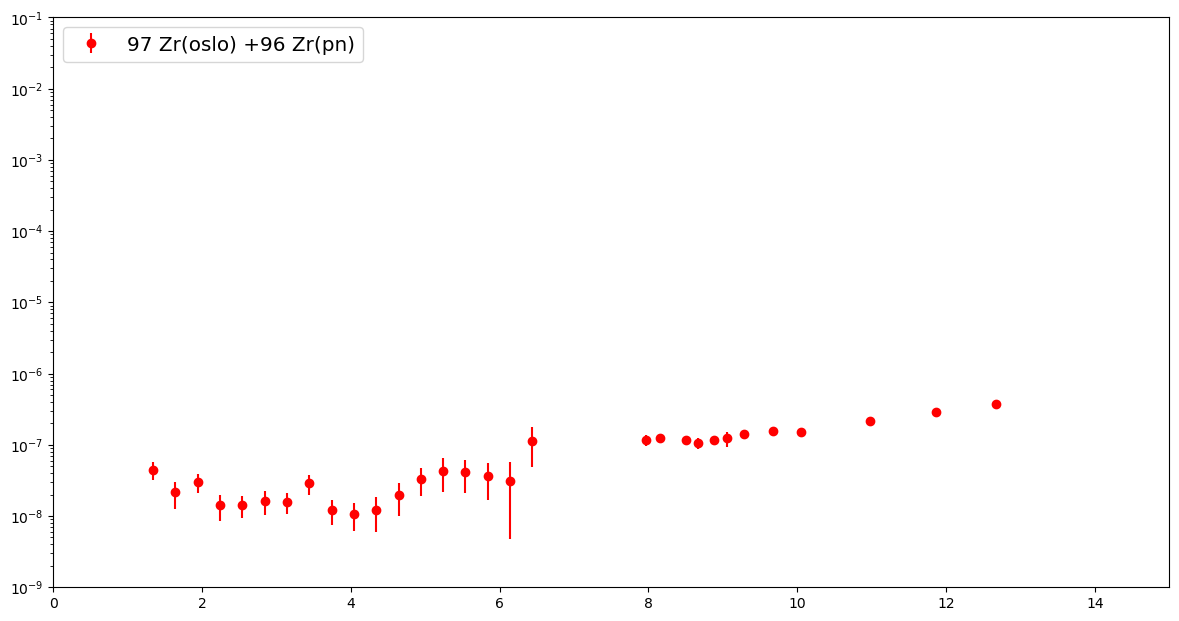

In [125]:
# Plot the oslo data  + additional data with error bars

fig = plt.figure()


plt.errorbar(energy, gsf,yerr=error,fmt="o", color="r",ecolor='r',label='97 Zr(oslo) +96 Zr(pn)')

plt.yscale("log")

plt.xlim(0, 15)
plt.ylim(10**(-9),10**(-1))

plt.legend(loc ='upper left',fontsize="x-large")
plt.show()

<font size="5">
The model we will use to fit to this data set is:
    
    

strength 8 , strength M1 2

In [127]:
# this is the base/default GSF you get from TALYS without applying any parameters.It has 6 columns has shown below 

df_construct = pd.read_pickle("master_base_gsf.pkl")

df_sample = df_construct.copy()

df_base = df_construct.copy()

df_base

,energy,f(M1),f(E1),T(M1),T(E1),gsf
0,0.001,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
1,0.002,1.052640e-12,0.000000e+00,5.291170e-20,0.000000,1.052640e-12
2,0.005,2.631610e-12,0.000000e+00,2.066860e-18,0.000000,2.631610e-12
3,0.010,5.263230e-12,0.000000e+00,3.306990e-17,0.000000,5.263230e-12
4,0.020,1.052650e-11,0.000000e+00,5.291210e-16,0.000000,1.052650e-11
...,...,...,...,...,...,...
64,18.500,8.292380e-10,6.087220e-07,3.298940e-05,0.024217,6.095512e-07
65,19.000,7.463810e-10,5.199900e-07,3.216630e-05,0.022410,5.207364e-07
66,19.500,6.746050e-10,4.450490e-07,3.142920e-05,0.020734,4.457236e-07
67,20.000,6.120730e-10,3.826850e-07,3.076610e-05,0.019236,3.832971e-07


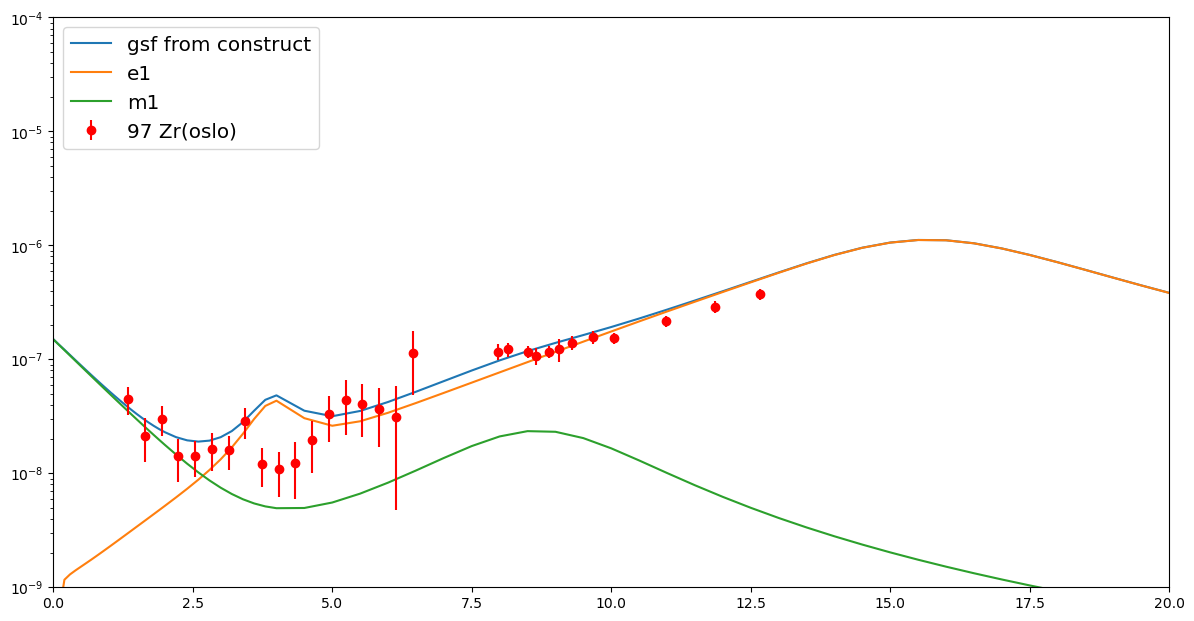

In [128]:

# selecting [ftable,upbende,upbendc] to be [1,1.1,1.5*10**(-7)] and construct it to just compare with actual data 

ftable=1

# these numbers from talys output file/construction for E1 upbend
C= 10**(-10)
U =  5.569156
eta =3



# pygmy values from talys output file
k = 8.673**(-8) 
epr = 4
spr =1
gpr =4


#f(M1)
upbende =1.1
upbendc = 1.5*10**(-7)

# f(e1) construction
df_sample['f(E1)']= ftable * df_construct['f(E1)']+  (C* (U-df_construct['energy']))/(1+np.exp(df_construct['energy']-eta)) \
                      + (k * gpr * df_construct['energy'] * spr**2) /((df_construct['energy']**2 - epr**2)**2 +df_construct['energy']**2 * spr**2)

#f(m1) construction
df_sample['f(M1)']=  df_construct['f(M1)']+  upbendc * np.exp(-1*upbende*df_construct['energy'])

df_sample['gsf'] = df_sample['f(E1)']+ df_sample['f(M1)']


plt.plot(df_sample['energy'], df_sample['gsf'], label ='gsf from construct')
plt.plot(df_sample['energy'], df_sample['f(E1)'], label ='e1')
plt.plot(df_sample['energy'], df_sample['f(M1)'], label ='m1')


plt.errorbar(energy, gsf,yerr=error,fmt="o", color="r",ecolor='r',label='97 Zr(oslo)')



plt.yscale("log")

plt.xlim(0, 20)
plt.ylim(10**(-9),10**(-4))

plt.legend(loc ='upper left',fontsize="x-large")
plt.show()



<font size="5">
Linear interpolation

In [179]:
#linear interpolation for the talys values on energy/x in the oslo data
# needed for the likelihood function


intp_gsf = np.interp(energy, df_sample['energy'].values, df_sample['gsf'].values)
intp_e1 = np.interp(energy,  df_sample['energy'].values, df_sample['f(E1)'].values)
intp_m1 = np.interp(energy, df_sample['energy'].values, df_sample['f(M1)'].values)



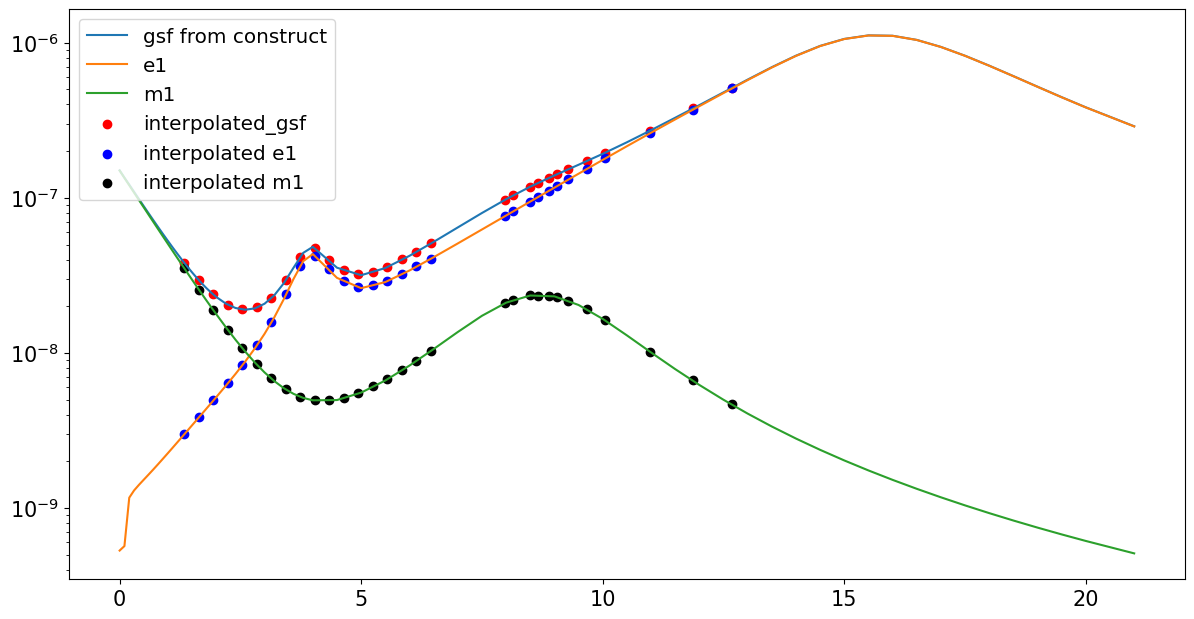

30


In [181]:
#verification whether the interpolation did its job!!! interpolated data vs model

fig = plt.figure()

plt.plot(df_sample['energy'], df_sample['gsf'], label ='gsf from construct')
plt.plot(df_sample['energy'], df_sample['f(E1)'], label ='e1')
plt.plot(df_sample['energy'], df_sample['f(M1)'], label ='m1')



plt.scatter(energy,intp_gsf,label='interpolated_gsf', color='r')
plt.scatter(energy, intp_e1, label ='interpolated e1' ,color ='blue')
plt.scatter(energy, intp_m1, label ='interpolated m1', color = 'black')




plt.yscale("log")

#plt.xlim(0, 10)
#plt.ylim(10**(-9),10**(-4))

plt.legend(loc ='upper left',fontsize="x-large")
plt.show()


print(intp_gsf.size)

Bayesian starts here

In [183]:
#intrapoltaion of base values on the oslo energy values

int_gsf = np.interp(energy, df_base['energy'].values, df_base['gsf'].values)
int_e1 = np.interp(energy,  df_base['energy'].values, df_base['f(E1)'].values)
int_m1 = np.interp(energy, df_base['energy'].values, df_base['f(M1)'].values)




In [211]:
# this is the function used to get the model GSF at each point of energy specified by the parameters sent by the MCMC algorithm

def model_8(j,params):

    # f(e1)  --- constants
    ftable=1
    C= 10**(-10)
    U =  5.569156
    eta =3



    
    # pygmy values
    k = 8.617**(-8) 
    
    #f(M1)-- constants
    upbende =1.1
    upbendc = 10**(-6)
    
    # f(e1) construction
    e1= params[0]*ftable * int_e1[j] +  (C* (U-energy[j]))/(1+np.exp(energy[j]-eta))\
    + (k * params[3] * int_e1[j] * params[4]**2) /((int_e1[j]**2 - params[5]**2)**2 +int_e1[j]**2 * params[4]**2)
    
       
    
    #f(m1) construction
    m1 = int_m1[j] +  params[1]*upbendc * np.exp(-1*(upbende*params[2])*energy[j])
    
    gsf_t = m1+e1
    
    return gsf_t


In [213]:
# this is a function that is used after the posterior has been found . Once we have the set of parameters from posterior , use this function to construct the 
# credible intevals

def model_all(params):

     # f(e1)  --- constants
    ftable=1
    C= 10**(-10)
    U =  5.569156
    eta =3


    # pygmy values
    k = 8.617**(-8)    
    
    
    #f(M1)-- constants
    upbende =1.1
    upbendc = 10**(-6)
    
    # f(e1) construction
    e1= params[0]*ftable *  df_base['f(E1)'].values +  (C* (U-df_base['energy'].values))/(1+np.exp( df_base['energy'].values-eta))\
     + (k * params[3] * df_base['energy'] * params[4]**2) /((df_base['energy']**2 - params[5]**2)**2 +df_base['energy']**2 * params[4]**2)
    
    #f(m1) construction
    m1 =  df_base['f(M1)'].values +  params[1]*upbendc * np.exp(-1*(upbende*params[2])*df_base['energy'].values)

    gsf_t2 = m1+e1
    
    return gsf_t2

In [227]:

# Define the likelihood function for given errors sigma
def likelihood(params,arguments):
#Assumed format for data=[xvals,yvals]
    data, model, sigmas = arguments
    likelihood_log_val=0

    for i in range(len(data[0])):
        likelihood_log_val=likelihood_log_val-1/2*((data[1][i] - model(i,params)) / sigmas[i])**2\
        -np.log(2*np.pi*sigmas[i]**2)/2
      
        
    return np.exp(likelihood_log_val)

def prior_model_8(params_vals,arguments):
    params0,params0_Cov_Inv_matrix=arguments


    else:
        mu=np.array(params_vals)-np.array(params0)
        params_size=len(params_vals)
        return (2*np.pi)**(-params_size/2)*np.sqrt(np.linalg.det(params0_Cov_Inv_matrix))*np.exp(-np.dot(mu,np.dot(params0_Cov_Inv_matrix,mu))/2)




In [228]:
# Define the Metropolis algorithm
def metropolis(data,sigma, prior,prior_arguments, likelihood,model,\
               num_iterations, step_size):
#     step_size should be a list the size of the parameters of the model
    likelihood_arguments=[data, model, sigma]
    initial_parameters=prior_arguments[0]
    #thermalizing
    burn_samples=10000
    # Set the initial state of the chain
    params_current=initial_parameters
    params_list=[]
    posterior_list=[]
    
    acceptance_times=0
    
    cov_step_size=np.diag(step_size)**2
    
    posterior_current=(likelihood(params_current,likelihood_arguments))*(prior(params_current,\
                                                                               prior_arguments))
    
    # Run the Metropolis-Hastings algorithm for burning
    for i in range(burn_samples):
        # Propose a new state for the chain
        params_proposed=np.random.multivariate_normal(params_current,cov_step_size)
        
        posterior_proposed=(likelihood(params_proposed,likelihood_arguments))*(prior(params_proposed,\
                                                                               prior_arguments))
        
        # Calculate the acceptance probability
        acceptance_prob = min(1, posterior_proposed / posterior_current)

        # Accept or reject the proposal
        if np.random.uniform() < acceptance_prob:
            params_current = params_proposed
            posterior_current=posterior_proposed


    for i in range(num_iterations):
        params_proposed=np.random.multivariate_normal(params_current,cov_step_size)
        
        posterior_proposed=(likelihood(params_proposed,likelihood_arguments))*\
        (prior(params_proposed,prior_arguments))
        
        # Calculate the acceptance probability
        acceptance_prob = min(1, posterior_proposed / posterior_current)

        # Accept or reject the proposal
        if np.random.uniform() < acceptance_prob:
            params_current = params_proposed
            posterior_current=posterior_proposed
            acceptance_times=acceptance_times+1

        # Store the current state
        params_list.append(params_current)
        posterior_list.append(posterior_current)
        
    
    #Rule of thumb acceptance is around 50%. 
    #You could plot the accuracy of the estimations as a function of this rate, that would be interesting to see. 
    print(acceptance_times/num_iterations*100,"%")
    
    return(np.array(params_list),np.array(posterior_list),\
           acceptance_times/num_iterations*100)




In [229]:

#Setting up the prior

prior_arguments_A=[[0.0,0.0,0.0,0,0,0],np.linalg.inv(np.diag([5**2,5**2,5**2,5**2,5**2,5**2]))]

#Doing the Metropolis sampling for 100000 values
results_A=metropolis([energy,gsf],error, prior_model_8,\
                         prior_arguments_A, likelihood,model_8,100000, [0.08,0.06,0.02,0.1,0.1,0.1])

all_chains =results_A[0]

print(all_chains)



34.708 %
[[ 8.67084351e-01  2.21655488e-01  1.30788922e+00 -1.03117680e+00
   6.52680624e-01 -2.81151364e-02]
 [ 8.67084351e-01  2.21655488e-01  1.30788922e+00 -1.03117680e+00
   6.52680624e-01 -2.81151364e-02]
 [ 8.67084351e-01  2.21655488e-01  1.30788922e+00 -1.03117680e+00
   6.52680624e-01 -2.81151364e-02]
 ...
 [ 8.31912891e-01  4.77448287e-01  1.61626657e+00 -1.29884585e+01
  -3.79148575e+01  2.31289856e+01]
 [ 8.31912891e-01  4.77448287e-01  1.61626657e+00 -1.29884585e+01
  -3.79148575e+01  2.31289856e+01]
 [ 8.31912891e-01  4.77448287e-01  1.61626657e+00 -1.29884585e+01
  -3.79148575e+01  2.31289856e+01]]


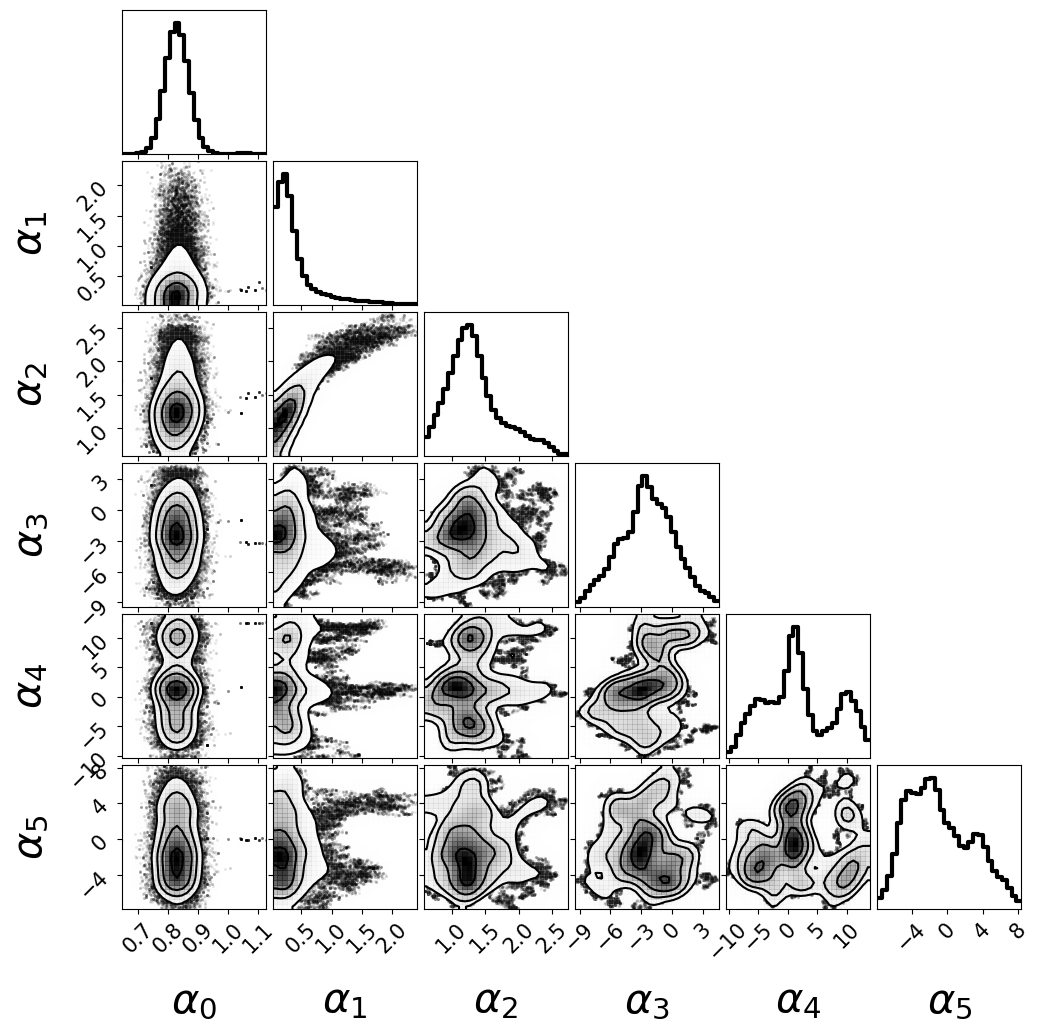

In [165]:
figure = corner.corner(
    all_chains,
    labels=[r'$\alpha_0$', r'$\alpha_1$', r'$\alpha_2$',r'$\alpha_3$',r'$\alpha_4$',r'$\alpha_5$'],
    labelpad=0.2,
    bins=30,
    label_kwargs={"fontsize":30},
    hist_kwargs={"linewidth":3},
    smooth=1.7,
    smooth1d=1.0
)

width, height = 10, 10  # bigger for 3 params
figure.set_size_inches(width, height)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)

#plt.savefig(r"contour plots_gsf.jpg", format='jpg', dpi=300, bbox_inches='tight')


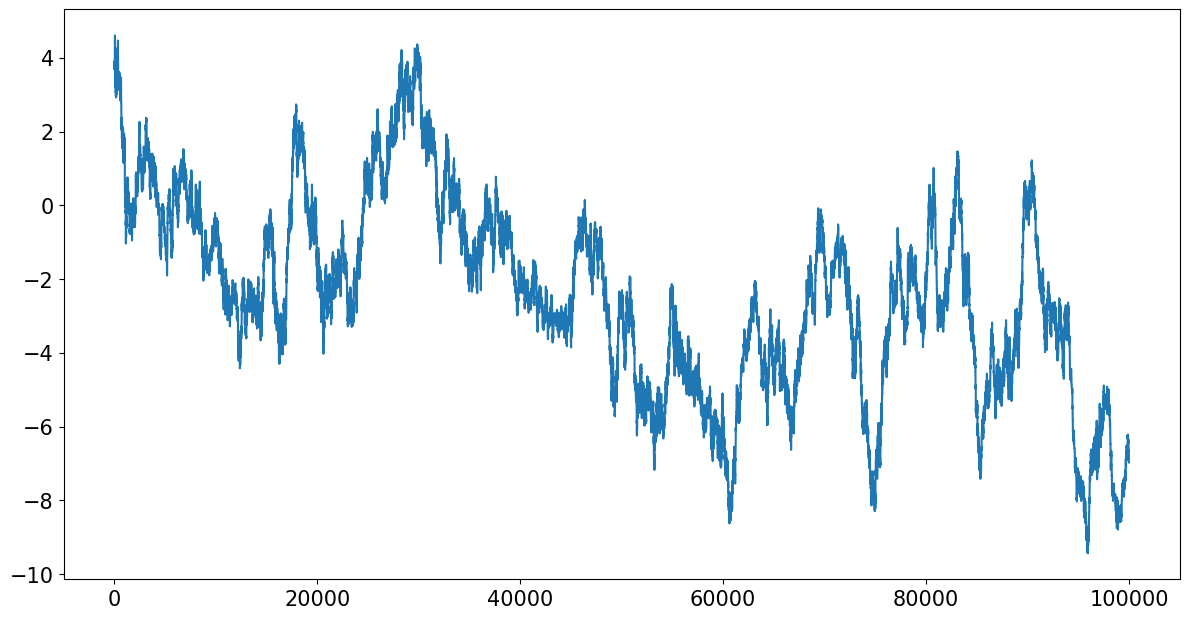

In [167]:
# to see how the walker walked over space
# change 0 to any number to see the walker
plt.plot(all_chains[:,3])

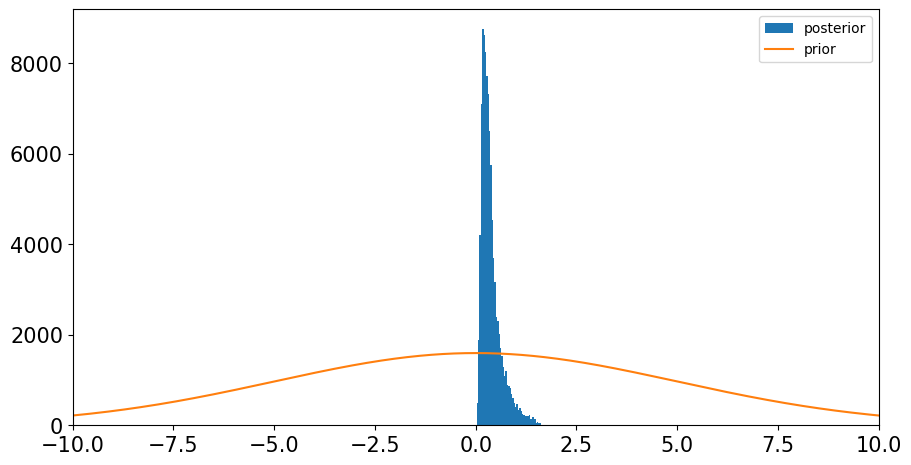

In [533]:

# to see how prior and posterior looks like

# posterior
plt.hist(all_chains[:,1], bins=50,label='posterior')


#prior with mean and width as previously specified
mu = 0    # center
sigma = 5   # standard deviation

x = np.linspace(mu - 2*sigma, mu + 2*sigma, 500)

y = 20000*(1/(sigma*np.sqrt(2*np.pi))) * np.exp(-(x-mu)**2/(2*sigma**2))

plt.plot(x, y,label='prior')

plt.xlim(-10,10)
#plt.plot(x, norm.pdf(x, mu, sigma))
plt.legend()
plt.show()


In [185]:
#Taking 10000 samples from the visited posterior to estimate the percentiles in the model predictions

rng = np.random.default_rng()
alpha_rand = rng.choice(all_chains,(10000),replace=False)


print(alpha_rand)


[[ 0.82343643  0.10411635  0.83597646 -2.66206655  8.8521527  -3.77763558]
 [ 0.77981936  0.09616109  0.84413597 -6.40190184 -2.43381924 -5.54947665]
 [ 0.81269773  0.55965288  1.76788439 -4.79255277  0.86905019 -1.07896333]
 ...
 [ 0.78094415  0.24481059  1.31838361 -0.59093173  4.24743373  3.17974795]
 [ 0.82251089  0.6942025   1.84207699  0.43869287 -6.5173699  -1.07073259]
 [ 0.80012992  0.17090251  1.07773747  1.09893831  0.23525281 -1.6119079 ]]


Lets make a plot of the predictions of our calibrated model

(69,)
(69,)


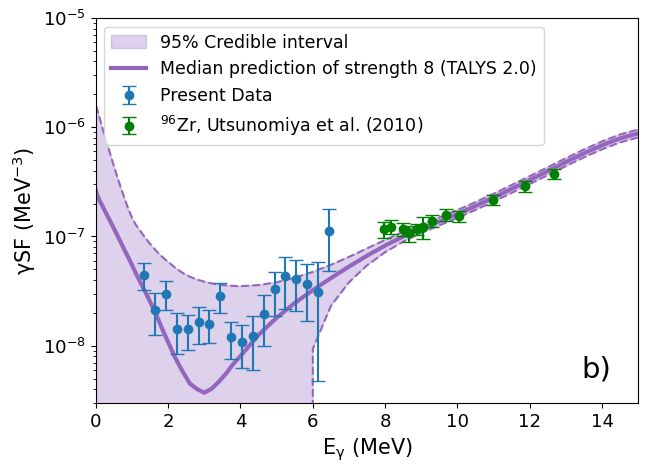

In [189]:
plt.rcParams['figure.figsize']=(10.4,5.4)



np.random.seed(142857)



# find the credible interval for models
func_rand=[model_all(alpha) for alpha in alpha_rand]

fig, ax = plt.subplots(figsize=(7,5),dpi=100)
median = np.percentile(func_rand, 50, axis = 0)
upper = (np.percentile(func_rand, 97.5, axis = 0))

prediction_color_number=4

lower = (np.percentile(func_rand, 2.5, axis = 0))


print(upper.shape)
print(lower.shape)

ax.fill_between(df_base['energy'].values, lower, upper, color=colors[prediction_color_number], alpha=0.3,label='95% Credible interval')

ax.plot(df_base['energy'].values, median, color=colors[prediction_color_number],linewidth=3,label='Median prediction of strength 8 (TALYS 2.0)')
ax.plot(df_base['energy'].values, lower, color=colors[prediction_color_number],linestyle='dashed')
ax.plot(df_base['energy'].values, upper, color=colors[prediction_color_number],linestyle='dashed')


#ax.plot(df8['energy'],df8['gsf'], color='black', label ='Initial fit of strength 8')
#ax.plot(df_base['energy'].values, func_rand[3072], color='green',linestyle='dashed')
#plt.plot(energy_t,gsf_t,color='r',label='strength 9 model')
#If you want to see the true function that generated these, uncomment the following line
# ax.plot(x_func, true_function_A(x_func), label='True Function',color='r', alpha=0.6)

ax.errorbar(energy1, gsf1, yerr=error1, fmt='o', capsize=5,label='Present Data')


ax.errorbar(energy2, gsf2, yerr=error2, fmt='o',color='green', capsize=5,label=r'$^{96}\mathrm{Zr}$, Utsunomiya et al. (2010)')



#plt.plot(energy_t,gsf_t,color='orange',label='gsf from talys ')


# other nearby isotope data points
df_92=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\other isotope and talys files\\92Zr_photonuclear.txt",delimiter=r"\s+")
df_92.columns=['energy','dE','gsf','errors']

df_94=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\other isotope and talys files\\94Zr_photonuclear.txt",delimiter=r"\s+")
df_94.columns=['energy','dE','gsf','errors']

df_96=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\other isotope and talys files\\96Zr_photonuclear.txt",delimiter=r"\s+")
df_96.columns=['energy','dE','gsf','errors']

#plt.plot(df1['energy'], df1['gsf'],color='b')
#plt.errorbar(df_92['energy'], df_92['gsf'],yerr= df_92['errors'],fmt="o", color="green",ecolor='green',label='$^{92}$Zr(photo-neutron)')

#plt.plot(df2['energy'], df2['gsf'],color='r')
#plt.errorbar(df_94['energy'], df_94['gsf'],yerr= df_94['errors'],fmt="o", color="r",ecolor='r',label='$^{94}$Zr(photo-neutron)')

#plt.plot(df3['energy'], df3['gsf'],color='black')
#plt.errorbar(df_96['energy'], df_96['gsf'],yerr= df_96['errors'],fmt="o", color="black",ecolor='black',label='$^{96}$Zr(photo-neutron)')



plt.legend(fontsize=15,frameon=True, edgecolor='black')



plt.yscale("log")



plt.xlim(0, 15)
plt.ylim(3*10**(-9),10**(-5))


ax.set_xlabel(r'E$_{\mathrm{\gamma}}$ ($\mathrm{MeV}$)', fontsize=15)
ax.set_ylabel(r'$\mathrm{\gamma}$SF (MeV$^{-3}$)',fontsize=15)

#plt.rc('xtick', labelsize=13)   
#plt.rc('ytick', labelsize=13)


plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)


plt.legend(loc ='upper left', fontsize=12.5)

ax.text(0.95, 0.05, 'b)', transform=ax.transAxes,
        fontsize=21, va='bottom', ha='right')

plt.savefig(r"bayesian_gsf.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()



What if we want to predict the value of f at a specific location? For example x=3

In [664]:
df_low=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\ANL_e1807_with_97Y_emphasis\\bayesian\\300(6,9)_test\\gsf_low.txt",delimiter=r"\s+",skiprows=2,header=None)
df_low.columns=['energy','f(M1)','f(E1)','T(M1)','T(E1)']
df_low['gsf'] = df_low['f(M1)'] + df_low['f(E1)']

df_low

,energy,f(M1),f(E1),T(M1),T(E1),gsf
0,0.001,9.989010e-08,9.633270e-10,6.276280e-16,1.503010e-17,1.008534e-07
1,0.002,9.978110e-08,9.638750e-10,5.015550e-15,1.202650e-16,1.007450e-07
2,0.005,9.945360e-08,9.655260e-10,7.811070e-14,1.880280e-15,1.004191e-07
3,0.010,9.891020e-08,9.682980e-10,6.214710e-13,1.505750e-14,9.987850e-08
4,0.020,9.783240e-08,9.739190e-10,4.917590e-12,1.207080e-13,9.880632e-08
...,...,...,...,...,...,...
64,18.500,6.558520e-10,4.324180e-07,2.609160e-05,1.720280e-02,4.330739e-07
65,19.000,5.903200e-10,3.703780e-07,2.544060e-05,1.596190e-02,3.709683e-07
66,19.500,5.335510e-10,3.177090e-07,2.485760e-05,1.480170e-02,3.182426e-07
67,20.000,4.840940e-10,2.736600e-07,2.433320e-05,1.375560e-02,2.741441e-07


In [665]:
df_high=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\ANL_e1807_with_97Y_emphasis\\bayesian\\300(6,9)_test\\gsf_high.txt",delimiter=r"\s+",skiprows=2,header=None)
df_high.columns=['energy','f(M1)','f(E1)','T(M1)','T(E1)']
df_high['gsf'] = df_high['f(M1)'] + df_high['f(E1)']

df_high

,energy,f(M1),f(E1),T(M1),T(E1),gsf
0,0.001,1.698130e-07,1.179800e-09,1.066970e-15,1.639030e-17,1.709928e-07
1,0.002,1.696280e-07,1.180680e-09,8.526420e-15,1.311630e-16,1.708087e-07
2,0.005,1.690710e-07,1.183340e-09,1.327880e-13,2.051350e-15,1.702543e-07
3,0.010,1.681460e-07,1.187800e-09,1.056500e-12,1.643670e-14,1.693338e-07
4,0.020,1.663130e-07,1.196830e-09,8.359820e-12,1.319130e-13,1.675098e-07
...,...,...,...,...,...,...
64,18.500,9.837780e-10,6.486260e-07,3.913740e-05,2.580420e-02,6.496098e-07
65,19.000,8.854800e-10,5.555670e-07,3.816100e-05,2.394290e-02,5.564525e-07
66,19.500,8.003270e-10,4.765630e-07,3.728650e-05,2.220260e-02,4.773633e-07
67,20.000,7.261410e-10,4.104890e-07,3.649980e-05,2.063340e-02,4.112151e-07


NameError: name 'energy_t' is not defined

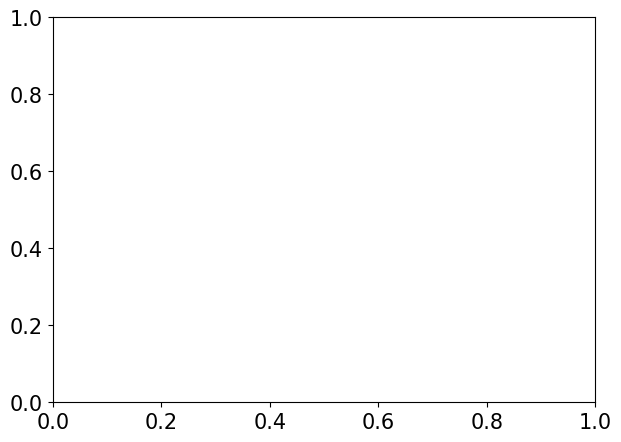

In [669]:
fig, ax = plt.subplots(figsize=(7,5),dpi=100)


ax.fill_between(energy_t, lower, upper, color=colors[prediction_color_number], alpha=0.3,label='95% Credible BAND')

ax.plot(energy_t, median, color=colors[prediction_color_number],linewidth=3,label='Median prediction')
ax.plot(energy_t, lower, color=colors[prediction_color_number],linestyle='dashed')
ax.plot(energy_t, upper, color=colors[prediction_color_number],linestyle='dashed')



#talys upper and lower tests

plt.plot(df_low['energy'], df_low['gsf'],color='red',label='strength-model8-talys-low')

plt.plot(df_high['energy'], df_high['gsf'],color='red',label='strength-model8-talys-high')

plt.legend(fontsize=15,frameon=True, edgecolor='black')
plt.yscale("log")
plt.xlim(0, 8)
#plt.ylim(10**(-9),10**(-5))


ax.set_xlabel('energy(MeV)',fontsize=20)
ax.set_ylabel('gsf',fontsize=20)

plt.rc('xtick', labelsize=20)   
plt.rc('ytick', labelsize=20)


plt.legend(loc ='upper left')
plt.show()